In [1]:
import pandas as pd
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.__version__

'2.3.3'

In [3]:
!pip install pyarrow

In [4]:
import urllib.request
import os

# Create a folder to store the data
os.makedirs('data', exist_ok=True)

# Define the list of URLs for the datasets you want
urls = [
    "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2023-01.parquet",
    "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2023-02.parquet"
]

# Loop through each URL and download it
for url in urls:
    # This automatically grabs the file name from the end of the link
    file_name = url.split('/')[-1]
    file_path = f"data/{file_name}"
    
    print(f"Downloading {file_name}...")
    urllib.request.urlretrieve(url, file_path)
    print(f"Download complete: {file_name}\n")

print("All datasets downloaded successfully!")

# Load and test just the green one to make sure Pandas is working
df = pd.read_parquet("data/green_tripdata_2023-01.parquet")
df.head()

Download complete: green_tripdata_2023-01.parquet

Download complete: green_tripdata_2023-02.parquet

All datasets downloaded successfully!


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.9,1.0,0.5,4.03,0.0,None,1.0,24.18,1.0,1.0,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.7,1.0,0.5,2.64,0.0,None,1.0,15.84,1.0,1.0,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.2,1.0,0.5,1.94,0.0,None,1.0,11.64,1.0,1.0,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.5,0.5,1.5,1.70,0.0,None,1.0,10.20,1.0,1.0,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.0,0.5,1.5,0.00,0.0,None,1.0,8.00,1.0,1.0,0.00


In [5]:
# If you find an error convert the datetime columns correctly using pd.to_datetime()

# df.lpep_dropoff_datetime - df.lpep_pickup_datetime
# create a duration column
df["duration"] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds()/60)

/tmp/ipykernel_2337/3426635498.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.duration)


<Axes: xlabel='duration', ylabel='Density'>

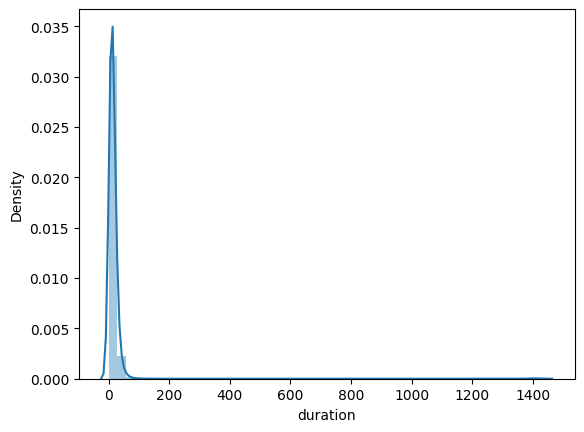

In [6]:
sns.distplot(df.duration)

In [7]:
df.duration.describe(percentiles=[0.95,0.98,0.99])

count    68211.000000
mean        18.097271
std         74.925631
min          0.000000
50%         11.400000
95%         33.266667
98%         45.616667
99%         58.115000
max       1439.883333
Name: duration, dtype: float64

In [8]:
# If you find an error convert the datetime columns correctly using pd.to_datetime()

# df.lpep_dropoff_datetime - df.lpep_pickup_datetime
# create a duration column
df["duration"] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds()/60)
# (df.duration >= 1) & (df.duration <= 60)
((df.duration >= 1) & (df.duration <= 60)).mean()

np.float64(0.9667942120772309)

In [9]:
categorical = ["PULocationID","DOLocationID"]
numerical = ["trip_distance"]
# df[categorical].dtypes
# Tuning
# df[categorical].astype(str).dtypes
df[categorical]=df[categorical].astype(str)


In [10]:
from sklearn.feature_extraction import DictVectorizer

# df[categorical+numerical].iloc[:10].to_dict(orient="records")
train_dicts = df[categorical+numerical].to_dict(orient="records")
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
target = "duration"
y_train = df[target].values

In [11]:
dv.feature_names_

['DOLocationID=1',
 'DOLocationID=10',
 'DOLocationID=100',
 'DOLocationID=101',
 'DOLocationID=102',
 'DOLocationID=106',
 'DOLocationID=107',
 'DOLocationID=108',
 'DOLocationID=11',
 'DOLocationID=111',
 'DOLocationID=112',
 'DOLocationID=113',
 'DOLocationID=114',
 'DOLocationID=115',
 'DOLocationID=116',
 'DOLocationID=117',
 'DOLocationID=119',
 'DOLocationID=12',
 'DOLocationID=120',
 'DOLocationID=121',
 'DOLocationID=122',
 'DOLocationID=123',
 'DOLocationID=124',
 'DOLocationID=125',
 'DOLocationID=126',
 'DOLocationID=127',
 'DOLocationID=128',
 'DOLocationID=129',
 'DOLocationID=13',
 'DOLocationID=130',
 'DOLocationID=131',
 'DOLocationID=132',
 'DOLocationID=133',
 'DOLocationID=134',
 'DOLocationID=135',
 'DOLocationID=136',
 'DOLocationID=137',
 'DOLocationID=138',
 'DOLocationID=139',
 'DOLocationID=14',
 'DOLocationID=140',
 'DOLocationID=141',
 'DOLocationID=142',
 'DOLocationID=143',
 'DOLocationID=144',
 'DOLocationID=145',
 'DOLocationID=146',
 'DOLocationID=147',

In [12]:
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc_taxi_experiment")


2026/07/19 15:29:10 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/19 15:29:10 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


<Experiment: artifact_location='/workspaces/MLOPS-camp/training/experiment_tracking/mlruns/1', creation_time=1784193660192, experiment_id='1', last_update_time=1784193660192, lifecycle_stage='active', name='nyc_taxi_experiment', tags={}>

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred))
rmse

# print("X_train shape:", X_train.shape)
# print("y_train shape:", y_train.shape)

np.float64(74.50020859598766)

In [14]:
df_val = pd.read_parquet("data/green_tripdata_2023-02.parquet")
val_dicts = df_val[categorical+numerical].to_dict(orient="records")
X_val = dv.transform(val_dicts)
df_val["duration"] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df_val.duration = df_val.duration.apply(lambda td: td.total_seconds()/60)
y_val = df_val[target].values

In [15]:
with open("models/lin_reg.bin","wb") as f_out:
    pickle.dump((dv,lr),f_out)
    

In [16]:
with mlflow.start_run():
    mlflow.set_tag("developer","nato")
    
    mlflow.log_param("train-data-path","./data/green_tripdata_2023-01.parquet")
    mlflow.log_param("valid-data-path","./data/green_tripdata_2023-02.parquet")
    
    alpha=0.1
    
    mlflow.log_param("alpha",alpha)
    
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    mlflow.log_metric("rmse",rmse)
    
    

/tmp/ipykernel_2337/2943976952.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label="prediction")


/tmp/ipykernel_2337/2943976952.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label="actual")


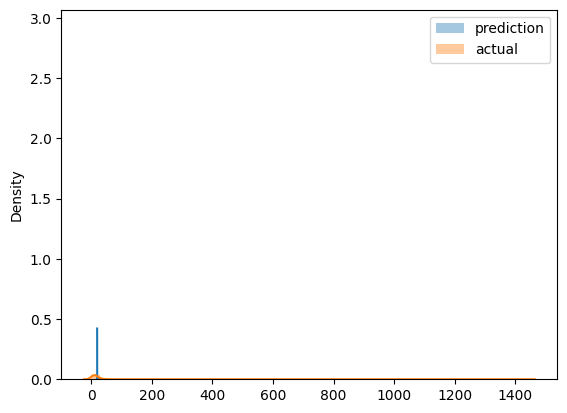

In [17]:
sns.distplot(y_pred, label="prediction")
sns.distplot(y_train, label="actual")
plt.legend()

In [18]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [19]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model","xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params = params,
            dtrain = train,
            num_boost_round=1000,
            evals=[(valid,"validation")],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
        mlflow.log_metric("rmse",rmse)
    return {"loss":rmse,"status":STATUS_OK}
        
     

In [21]:
train = xgb.DMatrix(X_train, label=y_train)
valid= xgb.DMatrix(X_val,label=y_val)

In [22]:
search_space = {
    "max_depth": scope.int(hp.quniform("max_depth", 4, 100, 1)),
    "learning_rate": hp.loguniform("learning_rate", -3, 0),
    "reg_alpha": hp.loguniform("reg_alpha", -5, -1),
    "reg_lambda": hp.loguniform("reg_lambda", -6, -1),
    "min_child_weight": hp.loguniform("min_child_weight", -1, 3),
    "objective": "reg:squarederror",  
    "seed": 42, 
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,      
    trials=Trials()
)

[0]	validation-rmse:76.82818                          
[1]	validation-rmse:76.87160                          
[2]	validation-rmse:76.92702                          
[3]	validation-rmse:76.98345                          
[4]	validation-rmse:77.03517                          
[5]	validation-rmse:77.08038                          
[6]	validation-rmse:77.12103                          
[7]	validation-rmse:77.15317                          
[8]	validation-rmse:77.17937                          
[9]	validation-rmse:77.20081                          
[10]	validation-rmse:77.21751                         
[11]	validation-rmse:77.23435                         
[12]	validation-rmse:77.24319                         
[13]	validation-rmse:77.25077                         
[14]	validation-rmse:77.25571                         
[15]	validation-rmse:77.26007                         
[16]	validation-rmse:77.26329                         
[17]	validation-rmse:77.26786                         
[18]	valid

In [24]:
with mlflow.start_run():

    train = xgb.DMatrix(X_train, label=y_train)
    valid= xgb.DMatrix(X_val,label=y_val)

    params = {"learning_rate":0.049792929803764575,
    "max_depth":
    8,
    "min_child_weight":
    10.402744863585303,
    "objective":
    "reg:squarederror",
    "reg_alpha":
    0.008683351515260418,
    "reg_lambda":
    0.010419794196532873,
    "seed":
    42
    }

    mlflow.log_params(params)


    mlflow.xgboost.autolog()
    booster = xgb.train(
                params = params,
                dtrain = train,
                num_boost_round=1000,
                evals=[(valid,"validation")],
                early_stopping_rounds=50
            )

    y_pred = booster.predict(valid)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        
    mlflow.log_metric("rmse",rmse)

    with open("models/preprocessor.b","wb")as f_out:
        pickle.dump(dv, f_out)

    mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")

    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")

[0]	validation-rmse:76.81636
[1]	validation-rmse:76.81612
[2]	validation-rmse:76.81733
[3]	validation-rmse:76.82098
[4]	validation-rmse:76.82584
[5]	validation-rmse:76.83087
[6]	validation-rmse:76.83732
[7]	validation-rmse:76.84417
[8]	validation-rmse:76.85214
[9]	validation-rmse:76.86040
[10]	validation-rmse:76.86887
[11]	validation-rmse:76.87800
[12]	validation-rmse:76.88781
[13]	validation-rmse:76.89714
[14]	validation-rmse:76.90555
[15]	validation-rmse:76.91508
[16]	validation-rmse:76.92516
[17]	validation-rmse:76.93491
[18]	validation-rmse:76.94392
[19]	validation-rmse:76.95256
[20]	validation-rmse:76.96185
[21]	validation-rmse:76.97014
[22]	validation-rmse:76.97652
[23]	validation-rmse:76.98428
[24]	validation-rmse:76.99163
[25]	validation-rmse:76.99931
[26]	validation-rmse:77.00678
[27]	validation-rmse:77.01371
[28]	validation-rmse:77.01982
[29]	validation-rmse:77.02676
[30]	validation-rmse:77.03272
[31]	validation-rmse:77.03865
[32]	validation-rmse:77.04469
[33]	validation-rmse

2026/07/19 15:46:34 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2026/07/19 15:46:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/19 15:46:34 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/codespace/anaconda3/envs/exp-tracking-env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:46:34] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."
2026/07/19 15:46:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/07/19 15:46:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `nam